## Используемые библиотеки

In [ ]:
from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)

from tensorflow.keras.datasets import mnist


import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


## Загрузка и подготовка данных

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 1, 32, 32), метки: (60000,)
Test : (10000, 1, 32, 32), метки: (10000,)
Диапазон: [0.00, 1.00]
Классы: [0 1 2 3 4 5 6 7 8 9]


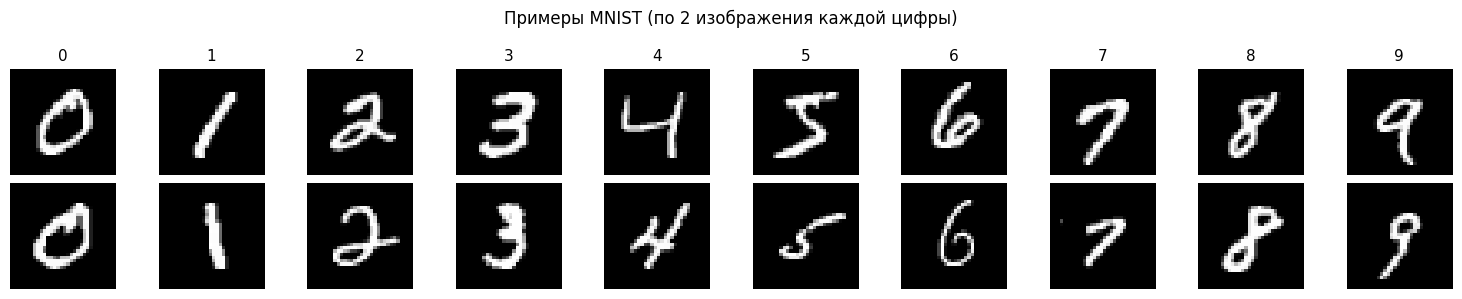


Обучающая подвыборка: (10000, 1, 32, 32)
Тестовая подвыборка:  (2000, 1, 32, 32)


In [ ]:
# ── Загрузка и подготовка MNIST ─────────────────────────────

(X_tr_raw, y_tr_raw), (X_te_raw, y_te_raw) = mnist.load_data()

# Нормализация в [0, 1]
X_tr_raw = X_tr_raw.astype(np.float64) / 255.0
X_te_raw = X_te_raw.astype(np.float64) / 255.0

# Добавляем ось канала: (N,28,28) → (N,1,28,28)
X_tr_raw = X_tr_raw[:, np.newaxis]
X_te_raw = X_te_raw[:, np.newaxis]

# Паддинг 28×28 → 32×32 (требование оригинального LeNet-5)
X_tr_mnist = np.pad(X_tr_raw, ((0,0),(0,0),(2,2),(2,2)))
X_te_mnist = np.pad(X_te_raw, ((0,0),(0,0),(2,2),(2,2)))

print(f'Train: {X_tr_mnist.shape}, метки: {y_tr_raw.shape}')
print(f'Test : {X_te_mnist.shape}, метки: {y_te_raw.shape}')
print(f'Диапазон: [{X_tr_mnist.min():.2f}, {X_tr_mnist.max():.2f}]')
print(f'Классы: {np.unique(y_tr_raw)}')

# Визуализация примеров
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for digit in range(10):
    idx = np.where(y_tr_raw == digit)[0][0]
    axes[0, digit].imshow(X_tr_mnist[idx, 0], cmap='gray')
    axes[0, digit].set_title(str(digit), fontsize=11)
    axes[0, digit].axis('off')
    idx2 = np.where(y_tr_raw == digit)[0][1]
    axes[1, digit].imshow(X_tr_mnist[idx2, 0], cmap='gray')
    axes[1, digit].axis('off')
plt.suptitle('Примеры MNIST (по 2 изображения каждой цифры)', fontsize=12)
plt.tight_layout()
plt.show()

# Для разумного времени обучения используем подвыборку
N_TRAIN = 10000
N_TEST  = 2000

np.random.seed(42)

tr_idx = np.random.permutation(len(X_tr_mnist))[:N_TRAIN]
te_idx = np.random.permutation(len(X_te_mnist))[:N_TEST]

X_tr4 = X_tr_mnist[tr_idx]; y_tr4 = y_tr_raw[tr_idx]
X_te4 = X_te_mnist[te_idx]; y_te4 = y_te_raw[te_idx]

print(f'\nОбучающая подвыборка: {X_tr4.shape}')
print(f'Тестовая подвыборка:  {X_te4.shape}')

## Ручная реализация

Epoch  1 | Loss: 0.6202 | Train Acc: 0.8232 | Val Acc: 0.9180
Epoch  2 | Loss: 0.2579 | Train Acc: 0.9257 | Val Acc: 0.9370
Epoch  3 | Loss: 0.1849 | Train Acc: 0.9461 | Val Acc: 0.9520
Epoch  4 | Loss: 0.1437 | Train Acc: 0.9599 | Val Acc: 0.9635
Epoch  5 | Loss: 0.1116 | Train Acc: 0.9681 | Val Acc: 0.9655
Epoch  6 | Loss: 0.0923 | Train Acc: 0.9735 | Val Acc: 0.9730
Epoch  7 | Loss: 0.0759 | Train Acc: 0.9798 | Val Acc: 0.9760
Epoch  8 | Loss: 0.0666 | Train Acc: 0.9812 | Val Acc: 0.9770
Epoch  9 | Loss: 0.0579 | Train Acc: 0.9841 | Val Acc: 0.9750
Epoch 10 | Loss: 0.0499 | Train Acc: 0.9865 | Val Acc: 0.9740
Epoch 11 | Loss: 0.0429 | Train Acc: 0.9896 | Val Acc: 0.9790
Epoch 12 | Loss: 0.0379 | Train Acc: 0.9915 | Val Acc: 0.9770
Epoch 13 | Loss: 0.0335 | Train Acc: 0.9929 | Val Acc: 0.9780
Epoch 14 | Loss: 0.0303 | Train Acc: 0.9937 | Val Acc: 0.9805
Epoch 15 | Loss: 0.0259 | Train Acc: 0.9953 | Val Acc: 0.9800

Отчёт по классам:
              precision    recall  f1-score   suppo

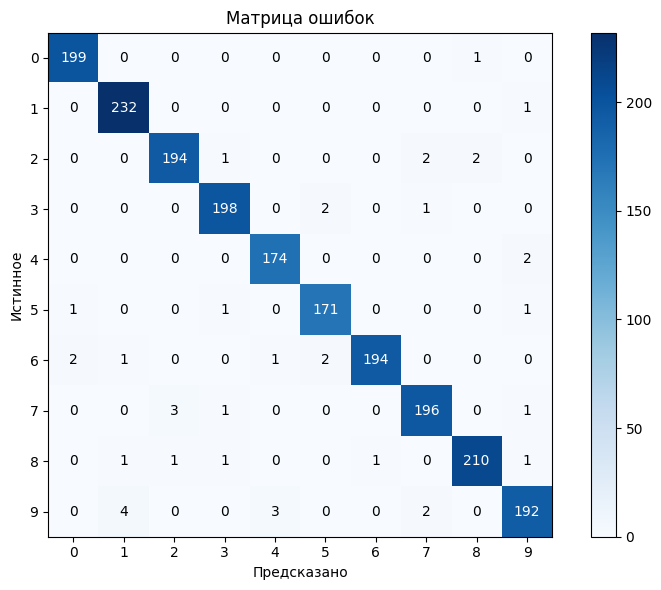

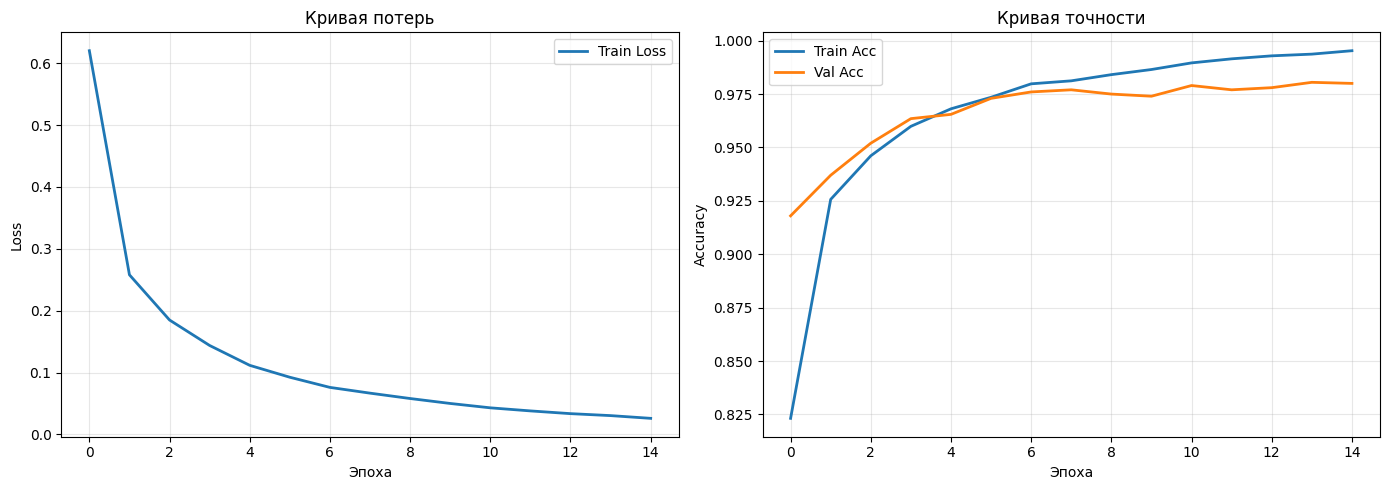

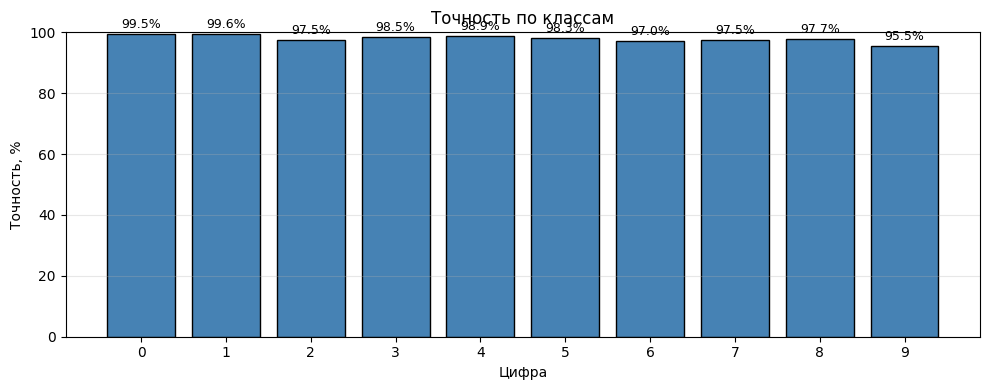


Итоговая точность на тесте: 98.00%


In [ ]:

# Слои
class Conv2D:
    def __init__(self, in_c, out_c, k, stride=1):
        self.in_c, self.out_c, self.k, self.s = in_c, out_c, k, stride
        lim = np.sqrt(6.0 / (in_c * k * k))
        self.W = np.random.uniform(-lim, lim, (out_c, in_c, k, k))
        self.b = np.zeros((out_c, 1))
        self.dW, self.db = np.zeros_like(self.W), np.zeros_like(self.b)
        self.mW, self.mb = np.zeros_like(self.W), np.zeros_like(self.b)

    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        H_out = (H - self.k) // self.s + 1
        W_out = (W - self.k) // self.s + 1
        self.H_out, self.W_out = H_out, W_out
        patches = np.lib.stride_tricks.sliding_window_view(x, (C, self.k, self.k), axis=(1, 2, 3))
        patches = patches.reshape(N * H_out * W_out, -1)
        out = patches @ self.W.reshape(self.out_c, -1).T + self.b.T
        return out.reshape(N, H_out, W_out, self.out_c).transpose(0, 3, 1, 2)

    def backward(self, dout):
        N = dout.shape[0]
        dout_flat = dout.transpose(0, 2, 3, 1).reshape(-1, self.out_c)
        self.db = dout_flat.sum(axis=0).reshape(-1, 1)
        patches = np.lib.stride_tricks.sliding_window_view(self.x, (self.in_c, self.k, self.k), axis=(1, 2, 3))
        patches = patches.reshape(N * self.H_out * self.W_out, -1)
        self.dW = (dout_flat.T @ patches).reshape(self.W.shape)
        dpatches = dout_flat @ self.W.reshape(self.out_c, -1)
        dpatches = dpatches.reshape(N, self.H_out, self.W_out, self.in_c, self.k, self.k)
        dx = np.zeros_like(self.x)
        for i in range(self.H_out):
            for j in range(self.W_out):
                dx[:, :, i*self.s:i*self.s+self.k, j*self.s:j*self.s+self.k] += dpatches[:, i, j]
        return dx

class AvgPool2D:
    def __init__(self, size=2): self.s = size
    def forward(self, x):
        self.x = x
        N, C, H, W = x.shape
        return x.reshape(N, C, H//self.s, self.s, W//self.s, self.s).mean(axis=(3, 5))
    def backward(self, dout):
        return np.repeat(np.repeat(dout, self.s, axis=2), self.s, axis=3) / (self.s**2)

class Tanh:
    def forward(self, x): self.out = np.tanh(x); return self.out
    def backward(self, dout): return dout * (1 - self.out**2)

class Linear:
    def __init__(self, in_f, out_f):
        lim = np.sqrt(6.0 / (in_f + out_f))
        self.W = np.random.uniform(-lim, lim, (in_f, out_f))
        self.b = np.zeros((1, out_f))
        self.dW, self.db = np.zeros_like(self.W), np.zeros_like(self.b)
        self.mW, self.mb = np.zeros_like(self.W), np.zeros_like(self.b)
    def forward(self, x): self.x = x; return x @ self.W + self.b
    def backward(self, dout):
        self.dW = self.x.T @ dout; self.db = dout.sum(axis=0, keepdims=True)
        return dout @ self.W.T

class Flatten:
    def forward(self, x): self.shape = x.shape; return x.reshape(x.shape[0], -1)
    def backward(self, dout): return dout.reshape(self.shape)

# Функция потерь и оптимизатор
def softmax_cross_entropy(logits, labels):
    exp = np.exp(logits - logits.max(axis=1, keepdims=True))
    probs = exp / exp.sum(axis=1, keepdims=True)
    N = logits.shape[0]
    loss = -np.log(probs[np.arange(N), labels] + 1e-8)
    grad = probs.copy(); grad[np.arange(N), labels] -= 1
    return loss.mean(), grad / N

class SGD:
    def __init__(self, layers, lr=0.01, momentum=0.9):
        self.layers, self.lr, self.mom = layers, lr, momentum
    def step(self):
        for l in self.layers:
            if hasattr(l, 'W'):
                l.mW = self.mom * l.mW - self.lr * l.dW; l.W += l.mW
                l.mb = self.mom * l.mb - self.lr * l.db; l.b += l.mb

# Модель LeNet-5
class LeNet5:
    def __init__(self):
        self.seq = [
            Conv2D(1, 6, 5), AvgPool2D(2), Tanh(),
            Conv2D(6, 16, 5), AvgPool2D(2), Tanh(),
            Conv2D(16, 120, 5), Tanh(), Flatten(),
            Linear(120, 84), Tanh(), Linear(84, 10)
        ]
    def forward(self, x):
        for l in self.seq: x = l.forward(x)
        return x
    def backward(self, dout):
        for l in reversed(self.seq): dout = l.backward(dout)

# Обучение
model = LeNet5()
opt = SGD(model.seq, lr=0.01, momentum=0.9)
epochs, bs = 15, 64
N = X_tr4.shape[0]
train_losses, train_accs, val_accs = [], [], []

for epoch in range(1, epochs + 1):
    perm = np.random.permutation(N)
    X_sh, y_sh = X_tr4[perm], y_tr4[perm]
    epoch_loss, correct, total = 0, 0, 0
    for i in range(0, N, bs):
        xb, yb = X_sh[i:i+bs], y_sh[i:i+bs]
        logits = model.forward(xb)
        loss, grad = softmax_cross_entropy(logits, yb)
        model.backward(grad)
        opt.step()
        epoch_loss += loss * xb.shape[0]
        correct += (np.argmax(logits, 1) == yb).sum()
        total += xb.shape[0]
    train_losses.append(epoch_loss / total)
    train_accs.append(correct / total)

    val_logits = model.forward(X_te4)
    val_accs.append((np.argmax(val_logits, 1) == y_te4).mean())
    print(f'Epoch {epoch:2d} | Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}')

#  Метрики
test_logits = model.forward(X_te4)
test_preds = np.argmax(test_logits, 1)

print("\nОтчёт по классам:")
print(classification_report(y_te4, test_preds, target_names=[str(i) for i in range(10)], digits=4))

cm = confusion_matrix(y_te4, test_preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Матрица ошибок')
plt.colorbar()
plt.xlabel('Предсказано'); plt.ylabel('Истинное')
plt.xticks(range(10)); plt.yticks(range(10))
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        plt.text(j, i, format(cm[i, j], 'd'), ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(train_losses, label='Train Loss', linewidth=2)
ax[0].set_xlabel('Эпоха'); ax[0].set_ylabel('Loss')
ax[0].set_title('Кривая потерь'); ax[0].grid(alpha=0.3); ax[0].legend()

ax[1].plot(train_accs, label='Train Acc', linewidth=2)
ax[1].plot(val_accs, label='Val Acc', linewidth=2)
ax[1].set_xlabel('Эпоха'); ax[1].set_ylabel('Accuracy')
ax[1].set_title('Кривая точности'); ax[1].grid(alpha=0.3); ax[1].legend()
plt.tight_layout(); plt.show()

class_acc = cm.diagonal() / cm.sum(axis=1) * 100
plt.figure(figsize=(10, 4))
bars = plt.bar(range(10), class_acc, color='steelblue', edgecolor='black')
plt.xlabel('Цифра'); plt.ylabel('Точность, %'); plt.title('Точность по классам')
plt.xticks(range(10)); plt.ylim(0, 100); plt.grid(axis='y', alpha=0.3)
for b, a in zip(bars, class_acc):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1, f'{a:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()

print(f"\nИтоговая точность на тесте: {accuracy_score(y_te4, test_preds)*100:.2f}%")